In [57]:
import numpy as np
import pandas as pd
import os
from tqdm import tqdm
from glob import glob
import random
from pathlib import Path
import pickle
import zipfile

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import cv2
import mediapipe as mp

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization, MaxPooling2D, SeparableConv2D
from keras.callbacks import ReduceLROnPlateau, EarlyStopping,  ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [78]:
# Constants
IMAGE_SIZE = 64
TRAIN_DIR = "asl_alphabet_dataset/asl_alphabet_train"
TEST_DIR = "asl_alphabet_dataset/asl_alphabet_test"

# Class mapping (29 ASL classes + 1 default)
CLASS_MAP = {
    'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7,
    'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14,
    'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21,
    'W': 22, 'X': 23, 'Y': 24, 'Z': 25, 'del': 26, 'nothing': 27, 'space': 28,
    'default': 29 
}

NUM_CLASSES = len(CLASS_MAP)  # 30 classes total

def load_data(folder_path, test_mode=False):
    X, y = [], []
    
    for class_name in os.listdir(folder_path):
        if class_name.startswith('.'):
            continue
            
        # Handle both train and test folder structures
        class_path = os.path.join(folder_path, class_name)
        if not os.path.isdir(class_path):
            if test_mode:
                class_name = os.path.splitext(class_name)[0].split('_')[0]
            else:
                continue
                
        label = CLASS_MAP.get(class_name.upper(), CLASS_MAP['default'])
        
        # Get all images in class directory
        img_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.png'))] if not test_mode else [class_path]
        
        for img_file in tqdm(img_files, desc=f"Loading {class_name}"):
            img_path = os.path.join(class_path, img_file) if not test_mode else class_path
            try:
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
                    img = img.astype('float32') / 255.0
                    X.append(img)
                    y.append(label)
            except Exception as e:
                print(f"Error loading {img_path}: {str(e)}")
    
    return np.array(X), np.array(y)

# Load training data
x_train, y_train = load_data(TRAIN_DIR)

# Load test data (handles different folder structure)
x_test, y_test = load_data(TEST_DIR, test_mode=True)

# Split validation set from training data if needed
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, 
    test_size=0.2, 
    random_state=42,
    stratify=y_train  # Maintain class balance
)

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val = to_categorical(y_val, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test, num_classes=NUM_CLASSES)

print(f"\nData loaded successfully:")
print(f"Train shapes: {x_train.shape}, {y_train.shape}")
print(f"Val shapes: {x_val.shape}, {y_val.shape}")
print(f"Test shapes: {x_test.shape}, {y_test.shape}")
print(f"Class distribution: {np.unique(y_train, return_counts=True)}")

Loading A:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading Z: 100%|██████████| 1/1 [00:00<00:00, 33.41it/s]



Data loaded successfully:
Train shapes: (69600, 64, 64, 3), (69600, 30)
Val shapes: (17400, 64, 64, 3), (17400, 30)
Test shapes: (28, 64, 64, 3), (28, 30)
Class distribution: (array([0., 1.]), array([2018400,   69600], dtype=int64))


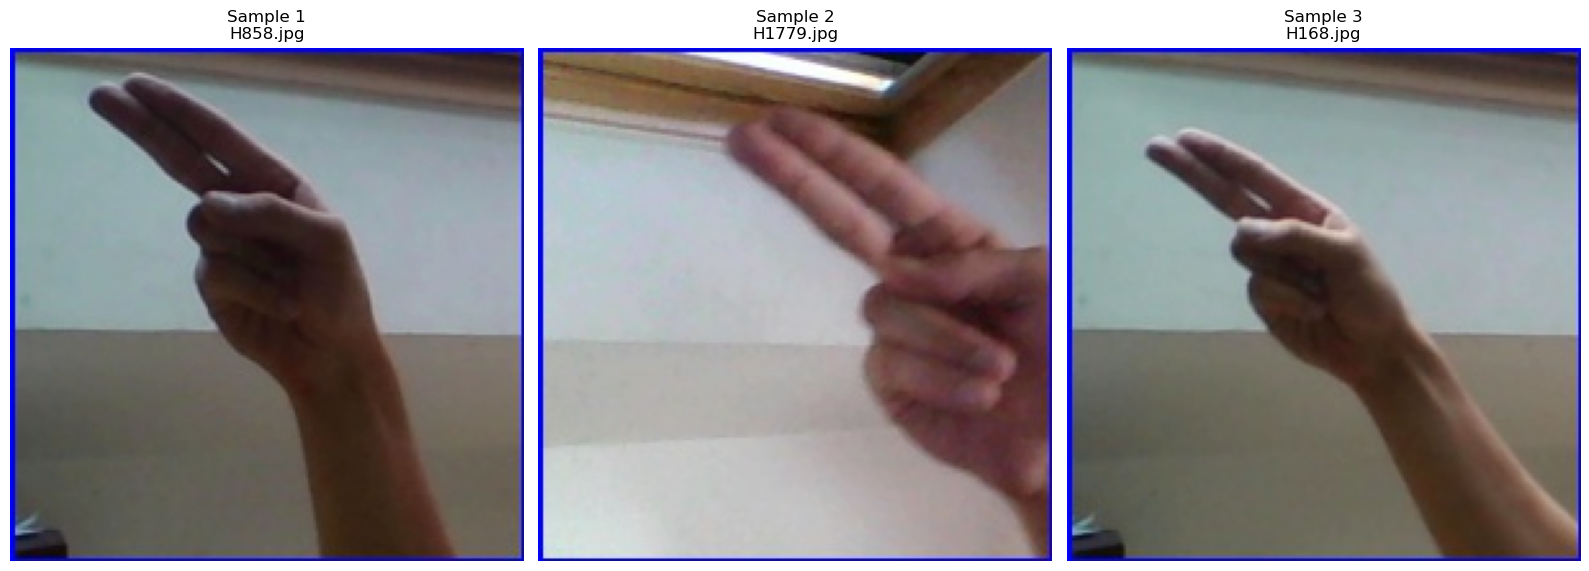

In [81]:
def plot_three_images(images):
    
    if len(images) < 3:
        print(f"Need at least 3 images, only found {len(images)}")
        return
    
    random_samples = random.sample(images, 3)
    
    plt.figure(figsize=(16, 6)) 
    for i, img_path in enumerate(random_samples, 1):
        img = cv2.imread(img_path)
        if img is None:
            print(f"Could not read image: {img_path}")
            continue
            
        # Convert BGR to RGB for proper matplotlib display
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, 3, i)
        plt.imshow(img_rgb)
        plt.title(f"Sample {i}\n{Path(img_path).name}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Example usage:
multiple_images = glob('asl_alphabet_dataset/asl_alphabet_train/H/*.jpg') 
plot_three_images(multiple_images)

In [85]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Flatten(),
    
    Dense(128, activation='relu'),
    Dense(30, activation='softmax')
])

model.compile(optimizer='adam',
              loss= 'categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 30)             │         3,870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687,070 (2.62 MB)

 Trainable params: 687,070 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

In [86]:
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True,  
    verbose=1
)

checkpoint = ModelCheckpoint(
    'cnn_alpha_final.keras',           
    monitor='val_loss', 
    save_best_only=True, 
    verbose=1
)

In [87]:
history = model.fit(x_train,y_train,
                    batch_size = 64,
                    epochs = 25, 
                    validation_data = (x_val, y_val) , 
                    callbacks=[early_stop, checkpoint]
                    )

Epoch 1/25
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.4998 - loss: 1.7121
Epoch 1: val_loss improved from inf to 0.23899, saving model to cnn_alpha_final.keras
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 173s 155ms/step - accuracy: 0.5000 - loss: 1.7113 - val_accuracy: 0.9197 - val_loss: 0.2390
Epoch 2/25
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9520 - loss: 0.1510
Epoch 2: val_loss improved from 0.23899 to 0.08537, saving model to cnn_alpha_final.keras
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 170s 156ms/step - accuracy: 0.9520 - loss: 0.1510 - val_accuracy: 0.9718 - val_loss: 0.0854
Epoch 3/25
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9784 - loss: 0.0678
Epoch 3: val_loss improved from 0.08537 to 0.08369, saving model to cnn_alpha_final.keras
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 171s 157ms/step - accuracy: 0.9784 - loss: 0.0678 - val_accuracy: 0.9732 - val_loss: 0.0837
Epoch 4/25
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.9864 - loss: 0.0477
Epoch

In [88]:
model.save('cnn_alpha_final01.keras')
model.save('cnn_alpha02_final01.h5')

In [89]:
test_loss, test_acc = model.evaluate(x_val, y_val, verbose=1)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

544/544 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.9971 - loss: 0.0078
Test accuracy: 0.9977
Test Loss: 0.0070


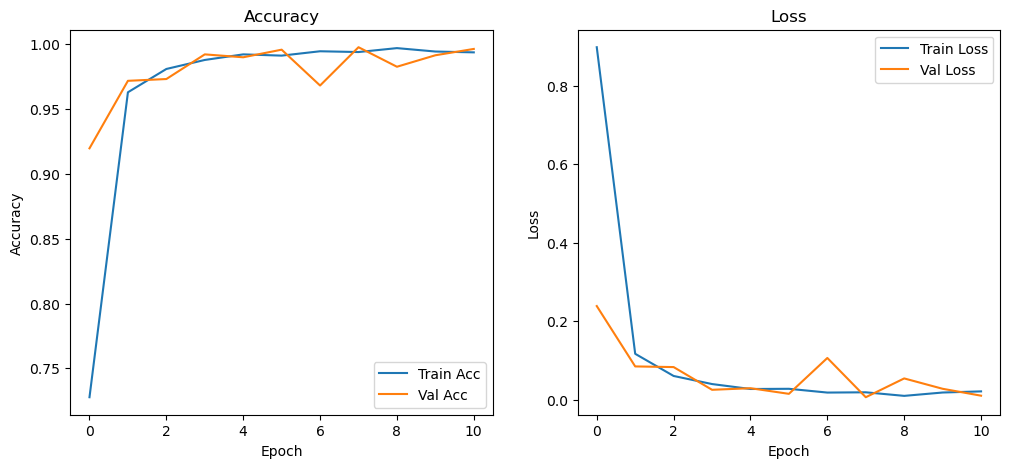

In [90]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

544/544 ━━━━━━━━━━━━━━━━━━━━ 39s 72ms/step
Classification Report for Validation:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       600
           1       1.00      1.00      1.00       600
           2       1.00      1.00      1.00       600
           3       1.00      0.99      1.00       600
           4       1.00      1.00      1.00       600
           5       1.00      1.00      1.00       600
           6       1.00      1.00      1.00       600
           7       1.00      1.00      1.00       600
           8       1.00      1.00      1.00       600
           9       1.00      1.00      1.00       600
          10       1.00      1.00      1.00       600
          11       1.00      1.00      1.00       600
          12       1.00      1.00      1.00       600
          13       1.00      1.00      1.00       600
          14       1.00      1.00      1.00       600
          15       1.00      0.99      1.00       600


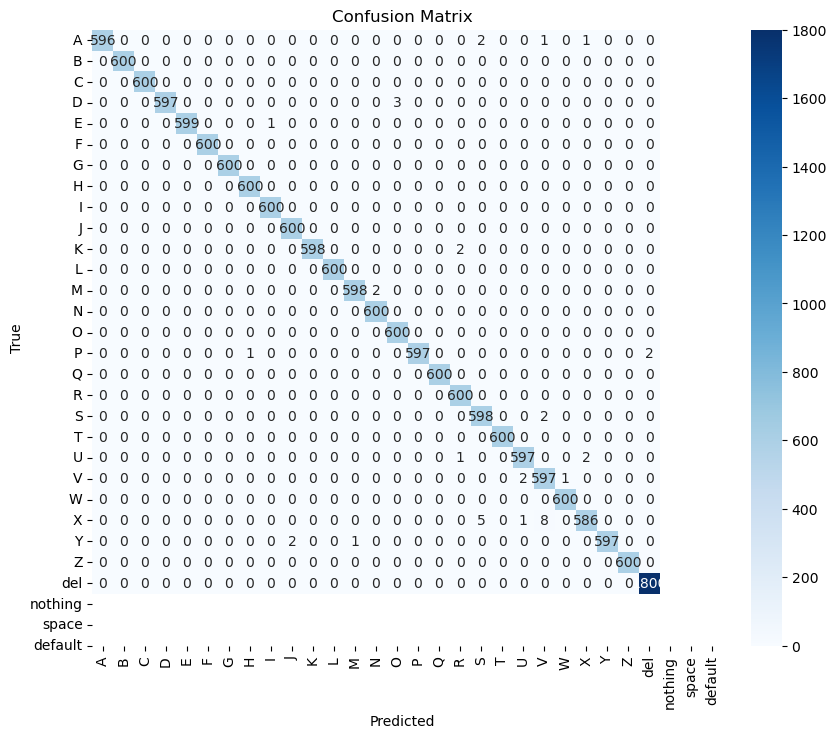

In [92]:
y_pred = model.predict(x_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

print("Classification Report for Validation:")
print(classification_report(y_true, y_pred_classes))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(CLASS_MAP.keys()),
            yticklabels=list(CLASS_MAP.keys()))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Classification Report for Validation:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      1.00      1.00         1
    

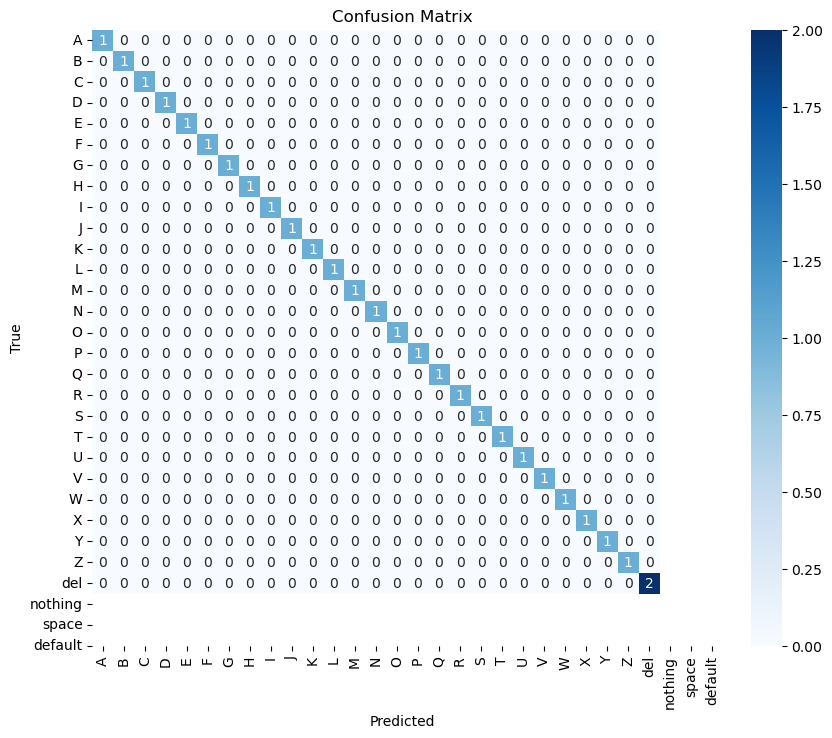

In [103]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Classification Report for Validation:")
print(classification_report(y_true, y_pred_classes))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(CLASS_MAP.keys()),
            yticklabels=list(CLASS_MAP.keys()))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()